# Assignment 2: Distributions, Outliers and Transformations

**Student names:** Alexeyenko Artyom and Akparov Dilshat

**Student IDs:** 37463 and 37341 

**Course:** Exploratory Data Analysis 

**Dataset:** `BankChurners.csv`


## 1. Setup and variable choice

The selected variables are:

- `Credit_Limit`: available credit capacity; it helps interpret utilisation and financial differences between customers.
- `Total_Trans_Amt`: total annual card spending; it was central to the transaction-activity and attrition questions.
- `Total_Trans_Ct`: total annual transaction count; it complements spending by measuring frequency.


In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 110
df = pd.read_csv('BankChurners.csv')
variables = ['Credit_Limit', 'Total_Trans_Amt', 'Total_Trans_Ct']
labels = {
    'Credit_Limit': 'Credit limit (USD)',
    'Total_Trans_Amt': 'Total transaction amount (USD)',
    'Total_Trans_Ct': 'Total transaction count'
}
df[variables].shape

(10127, 3)

## Part 1. Exploring distributions

For every selected variable, we calculate the requested descriptive statistics, then inspect a histogram and boxplot. Density plots are also included for the two noticeably skewed monetary variables.

In [44]:
import numpy as np
import pandas as pd
from IPython.display import display
df = pd.read_csv('BankChurners.csv')
variables = ['Credit_Limit', 'Total_Trans_Amt', 'Total_Trans_Ct']

def descriptive_statistics(frame, columns):
    rows = []
    for col in columns:
        s = frame[col]
        q1, q3 = s.quantile([0.25, 0.75])
        rows.append({
            'Variable': col, 'Mean': s.mean(), 'Median': s.median(),
            'Minimum': s.min(), 'Maximum': s.max(), 'Q1': q1, 'Q3': q3,
            'Std. deviation': s.std(), 'IQR': q3 - q1, 'Skewness': s.skew()
        })
    return pd.DataFrame(rows).set_index('Variable')

stats = descriptive_statistics(df, variables)
display(stats.round(2))

,Mean,Median,Minimum,Maximum,Q1,Q3,Std. deviation,IQR,Skewness
Variable,,,,,,,,,
Credit_Limit,8631.95,4549.0,1438.3,34516.0,2555.0,11067.5,9088.78,8512.5,1.67
Total_Trans_Amt,4404.09,3899.0,510.0,18484.0,2155.5,4741.0,3397.13,2585.5,2.04
Total_Trans_Ct,64.86,67.0,10.0,139.0,45.0,81.0,23.47,36.0,0.15


### 1.1 Credit limit

The typical customer has a credit limit of **$4,549** (median), whereas the mean is much higher at **$8,632**. The middle 50% spans $2,555 to $11,067.50 (IQR = $8,512.50), and the full range is $1,438.30 to $34,516. The long upper tail and skewness of **1.67** show a strongly right-skewed distribution. The median is therefore the more representative summary. The high values are plausible credit limits, but they deserve outlier investigation rather than automatic deletion.

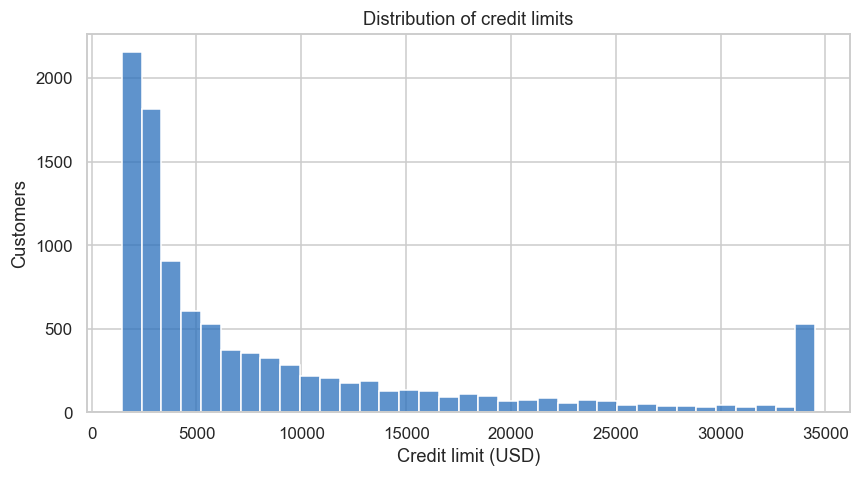

In [45]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv('BankChurners.csv')
labels = {'Credit_Limit': 'Credit limit (USD)'}

plt.figure(figsize=(8, 4.5))
sns.histplot(df, x='Credit_Limit', bins=35, color='#2a6fbb', edgecolor='white')
plt.title('Distribution of credit limits')
plt.xlabel(labels['Credit_Limit'])
plt.ylabel('Customers')
plt.tight_layout()
plt.show()

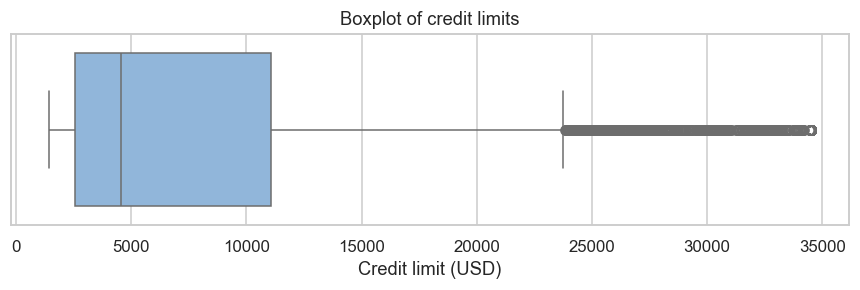

In [46]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv('BankChurners.csv')
labels = {'Credit_Limit': 'Credit limit (USD)'}

plt.figure(figsize=(8, 2.8))
sns.boxplot(x=df['Credit_Limit'], color='#85b6e6')
plt.title('Boxplot of credit limits')
plt.xlabel(labels['Credit_Limit'])
plt.tight_layout()
plt.show()

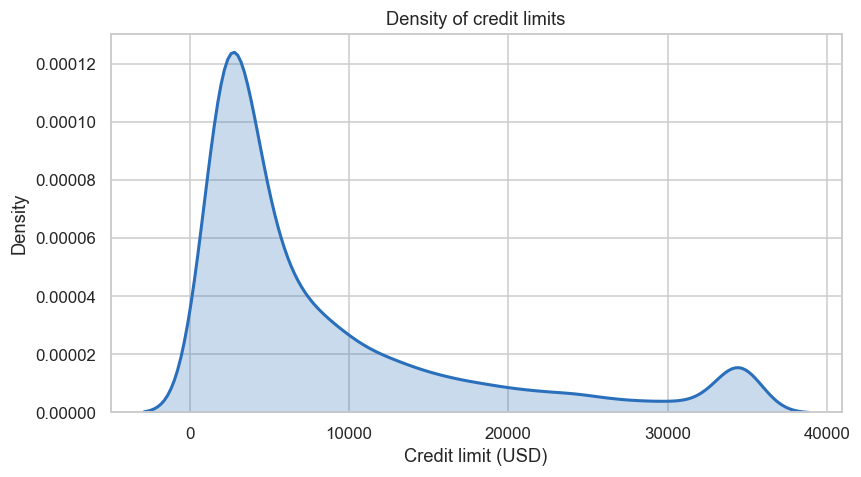

In [47]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv('BankChurners.csv')
labels = {'Credit_Limit': 'Credit limit (USD)'}

plt.figure(figsize=(8, 4.5))
sns.kdeplot(data=df, x='Credit_Limit', fill=True, color='#2a6fbb', linewidth=2)
plt.title('Density of credit limits')
plt.xlabel(labels['Credit_Limit'])
plt.ylabel('Density')
plt.tight_layout()
plt.show()

### 1.2 Total transaction amount

Annual transaction amount has a median of **$3,899** and a mean of **$4,404.09**. Its middle 50% lies between $2,155.50 and $4,741 (IQR = $2,585.50), but the maximum is $18,484. With skewness **2.04**, this is the most skewed of the three original variables. The distribution is right-skewed with unusually high but potentially genuine spending values; the median is the safer description of a typical customer.

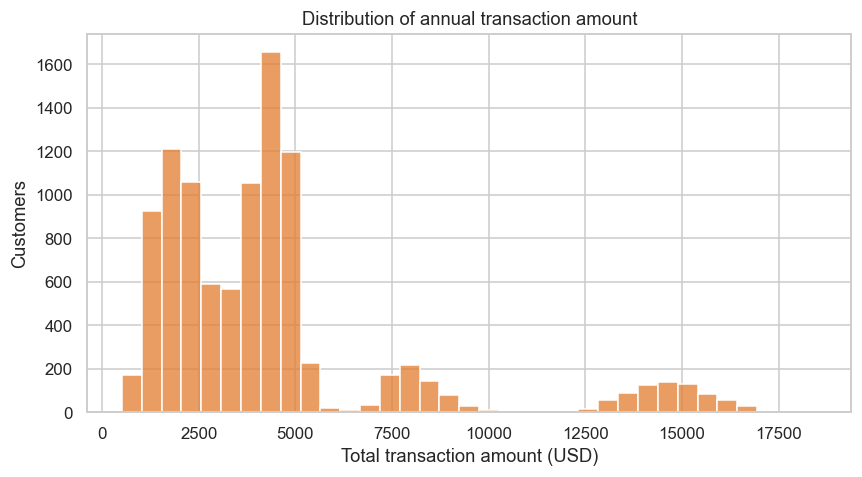

In [48]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv('BankChurners.csv')
labels = {'Total_Trans_Amt': 'Total transaction amount (USD)'}

plt.figure(figsize=(8, 4.5))
sns.histplot(df, x='Total_Trans_Amt', bins=35, color='#e27d2f', edgecolor='white')
plt.title('Distribution of annual transaction amount')
plt.xlabel(labels['Total_Trans_Amt'])
plt.ylabel('Customers')
plt.tight_layout()
plt.show()

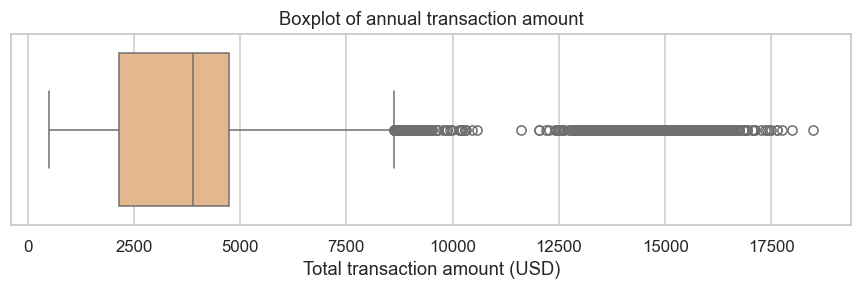

In [49]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv('BankChurners.csv')
labels = {'Total_Trans_Amt': 'Total transaction amount (USD)'}

plt.figure(figsize=(8, 2.8))
sns.boxplot(x=df['Total_Trans_Amt'], color='#f2b880')
plt.title('Boxplot of annual transaction amount')
plt.xlabel(labels['Total_Trans_Amt'])
plt.tight_layout()
plt.show()

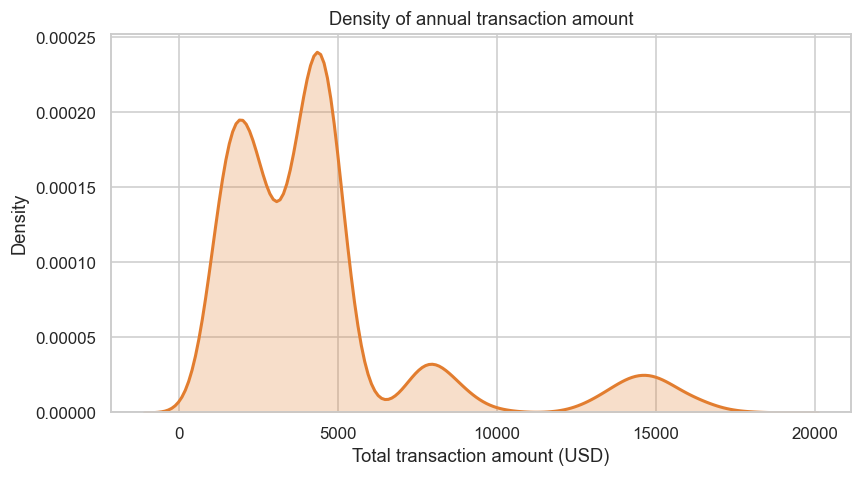

In [50]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv('BankChurners.csv')
labels = {'Total_Trans_Amt': 'Total transaction amount (USD)'}

plt.figure(figsize=(8, 4.5))
sns.kdeplot(data=df, x='Total_Trans_Amt', fill=True, color='#e27d2f', linewidth=2)
plt.title('Density of annual transaction amount')
plt.xlabel(labels['Total_Trans_Amt'])
plt.ylabel('Density')
plt.tight_layout()
plt.show()

### 1.3 Total transaction count

Transaction frequency is comparatively regular: mean **64.86**, median **67**, standard deviation **23.47**, and IQR **36** (Q1 = 45; Q3 = 81). Values range from 10 to 139. Skewness is only **0.15**, so the distribution is approximately symmetric, although it has a slight lower-side concentration. Mean and median are close; either is informative, with the median slightly more resistant to the two extreme high counts.

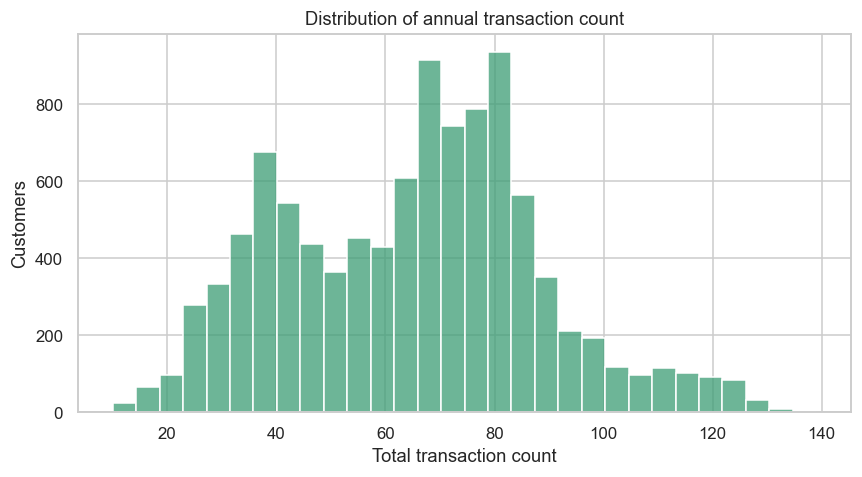

In [51]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv('BankChurners.csv')
labels = {'Total_Trans_Ct': 'Total transaction count'}

plt.figure(figsize=(8, 4.5))
sns.histplot(df, x='Total_Trans_Ct', bins=30, color='#3c9d75', edgecolor='white')
plt.title('Distribution of annual transaction count')
plt.xlabel(labels['Total_Trans_Ct'])
plt.ylabel('Customers')
plt.tight_layout()
plt.show()

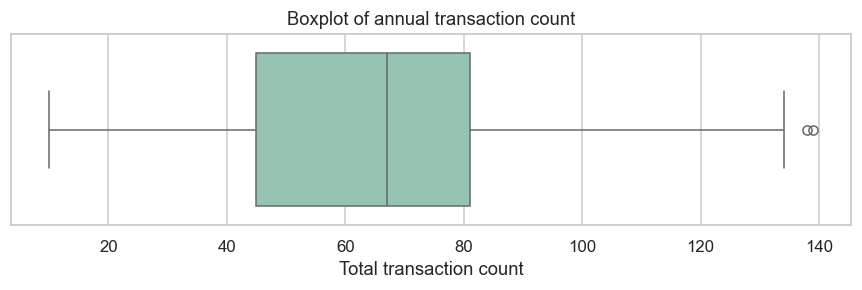

In [52]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv('BankChurners.csv')
labels = {'Total_Trans_Ct': 'Total transaction count'}

plt.figure(figsize=(8, 2.8))
sns.boxplot(x=df['Total_Trans_Ct'], color='#90cbb3')
plt.title('Boxplot of annual transaction count')
plt.xlabel(labels['Total_Trans_Ct'])
plt.tight_layout()
plt.show()

## Part 2. Comparing mean and median

The absolute difference is reported in the units of each variable. A large positive mean-minus-median difference is consistent with the influence of an upper tail.

In [53]:
import pandas as pd
from IPython.display import display
df = pd.read_csv('BankChurners.csv')
variables = ['Credit_Limit', 'Total_Trans_Amt', 'Total_Trans_Ct']
stats = pd.DataFrame({
    col: {'Mean': df[col].mean(), 'Median': df[col].median()} for col in variables
}).T

mean_median = stats[['Mean', 'Median']].copy()
mean_median['Difference (mean - median)'] = mean_median['Mean'] - mean_median['Median']
mean_median['Interpretation'] = [
    'Large positive gap: upper-tail credit limits lift the mean.',
    'Positive gap: high-spending customers lift the mean.',
    'Small negative gap: approximately symmetric distribution.'
]
display(mean_median.round(2))

,Mean,Median,Difference (mean - median),Interpretation
Credit_Limit,8631.95,4549.0,4082.95,Large positive gap: upper-tail credit limits l...
Total_Trans_Amt,4404.09,3899.0,505.09,Positive gap: high-spending customers lift the...
Total_Trans_Ct,64.86,67.0,-2.14,Small negative gap: approximately symmetric di...


**Answers.** `Credit_Limit` has the largest numerical gap between mean and median (**$4,082.95**). It is explained by a substantial group of high-limit customers in the right tail. The positive gaps for `Credit_Limit` and `Total_Trans_Amt` indicate right skewness; the small -2.14 gap for `Total_Trans_Ct` does not. We would use the **median and IQR** to describe credit limit and transaction amount, and either the **mean and standard deviation** or median and IQR for transaction count because its shape is close to symmetric.

## Part 3. Outlier investigation

Potential outliers are identified with the 1.5 × IQR rule. This is a screening rule, not proof that a record is incorrect.

In [54]:
import pandas as pd
from IPython.display import display
df = pd.read_csv('BankChurners.csv')
variables = ['Credit_Limit', 'Total_Trans_Amt', 'Total_Trans_Ct']

def iqr_outlier_summary(frame, columns):
    records = []
    masks = {}
    for col in columns:
        q1, q3 = frame[col].quantile([0.25, 0.75])
        iqr = q3 - q1
        lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
        mask = (frame[col] < lower) | (frame[col] > upper)
        masks[col] = mask
        records.append({
            'Variable': col, 'Q1': q1, 'Q3': q3, 'IQR': iqr,
            'Lower bound': lower, 'Upper bound': upper,
            'Potential outliers': int(mask.sum()), 'Percent': 100 * mask.mean()
        })
    return pd.DataFrame(records).set_index('Variable'), masks

outlier_summary, outlier_masks = iqr_outlier_summary(df, variables)
display(outlier_summary.round(2))

,Q1,Q3,IQR,Lower bound,Upper bound,Potential outliers,Percent
Variable,,,,,,,
Credit_Limit,2555.0,11067.5,8512.5,-10213.75,23836.25,984,9.72
Total_Trans_Amt,2155.5,4741.0,2585.5,-1722.75,8619.25,896,8.85
Total_Trans_Ct,45.0,81.0,36.0,-9.00,135.00,2,0.02


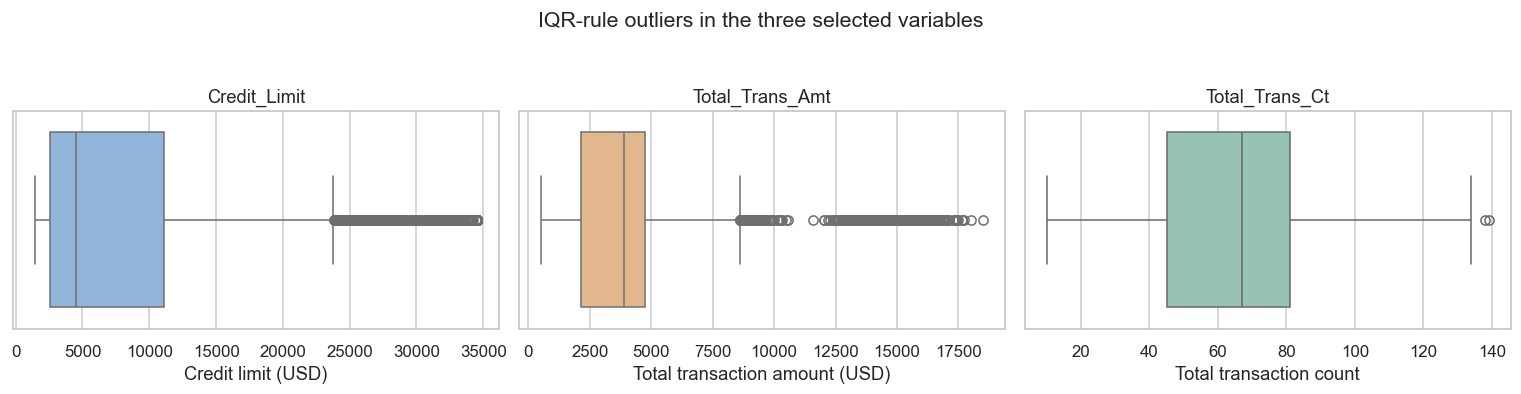

In [55]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv('BankChurners.csv')
variables = ['Credit_Limit', 'Total_Trans_Amt', 'Total_Trans_Ct']
labels = {'Credit_Limit': 'Credit limit (USD)', 'Total_Trans_Amt': 'Total transaction amount (USD)', 'Total_Trans_Ct': 'Total transaction count'}
outlier_rows = []
for col in variables:
    q1, q3 = df[col].quantile([0.25, 0.75])
    outlier_rows.append({'Variable': col, 'Potential outliers': int(((df[col] < q1 - 1.5 * (q3 - q1)) | (df[col] > q3 + 1.5 * (q3 - q1))).sum())})
outlier_summary = pd.DataFrame(outlier_rows).set_index('Variable')

fig, axes = plt.subplots(1, 3, figsize=(14, 3.4))
palette = ['#85b6e6', '#f2b880', '#90cbb3']
for ax, col, color in zip(axes, variables, palette):
    sns.boxplot(x=df[col], ax=ax, color=color)
    ax.set_title(col)
    ax.set_xlabel(labels[col])
fig.suptitle('IQR-rule outliers in the three selected variables', y=1.05, fontsize=14)
plt.tight_layout()
plt.show()

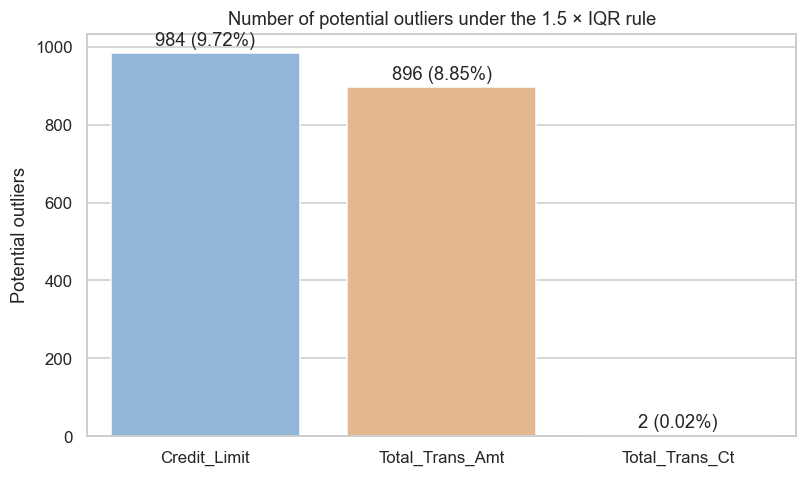

In [56]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv('BankChurners.csv')
variables = ['Credit_Limit', 'Total_Trans_Amt', 'Total_Trans_Ct']
outlier_rows = []
for col in variables:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    mask = (df[col] < q1 - 1.5 * iqr) | (df[col] > q3 + 1.5 * iqr)
    outlier_rows.append({'Variable': col, 'Potential outliers': int(mask.sum()), 'Percent': 100 * mask.mean()})
outlier_summary = pd.DataFrame(outlier_rows).set_index('Variable')
palette = ['#85b6e6', '#f2b880', '#90cbb3']

outlier_plot = outlier_summary.reset_index()
plt.figure(figsize=(7.5, 4.5))
sns.barplot(data=outlier_plot, x='Variable', y='Potential outliers', hue='Variable', legend=False, palette=palette)
for i, row in outlier_plot.iterrows():
    plt.text(i, row['Potential outliers'] + 20, f"{int(row['Potential outliers'])} ({row['Percent']:.2f}%)", ha='center')
plt.title('Number of potential outliers under the 1.5 × IQR rule')
plt.xlabel('')
plt.ylabel('Potential outliers')
plt.tight_layout()
plt.show()

In [57]:
import pandas as pd
from IPython.display import display
df = pd.read_csv('BankChurners.csv')

selected_outliers = pd.DataFrame([
    df.loc[df['Credit_Limit'].idxmax()],
    df.loc[df['Total_Trans_Amt'].idxmax()],
    df.loc[df['Total_Trans_Ct'].idxmax()]
])[['CLIENTNUM', 'Attrition_Flag', 'Customer_Age', 'Income_Category', 'Card_Category',
    'Credit_Limit', 'Total_Trans_Amt', 'Total_Trans_Ct', 'Avg_Utilization_Ratio']]
display(selected_outliers.reset_index(drop=True))

,CLIENTNUM,Attrition_Flag,Customer_Age,Income_Category,Card_Category,Credit_Limit,Total_Trans_Amt,Total_Trans_Ct,Avg_Utilization_Ratio
0,810347208,Existing Customer,51,$120K +,Gold,34516.0,1330,31,0.066
1,718140783,Existing Customer,47,$60K - $80K,Blue,10585.0,18484,108,0.165
2,708163758,Existing Customer,41,$120K +,Blue,34516.0,13085,139,0.018


### Investigation of three potential outliers

1. **Customer 810347208: credit limit = $34,516.** This is the maximum and exceeds the $23,836.25 upper IQR bound. It is possible for a 51-year-old customer in the `$120K +` income category with a Gold card. The low utilisation ratio (0.066) explains why high capacity does not imply high current borrowing. **Decision: keep.** It is a plausible high-limit customer, not a data-entry error.
2. **Customer 718140783: transaction amount = $18,484.** This exceeds the $8,619.25 upper bound. The customer has 108 transactions, which supports the interpretation that the large amount comes from very active card use rather than a misplaced decimal. **Decision: keep.** It is an informative, unusual spending profile.
3. **Customer 708163758: transaction count = 139.** This is above the upper bound of 135, but it is only four transactions beyond it. The customer also has $13,085 in annual transactions and a $34,516 credit limit, making the count coherent. **Decision: keep.** It is a plausible frequent user.

All three examined observations are retained. No evidence indicates a data-entry error, and removing genuine extreme customers would hide meaningful heterogeneity.

## Part 4. Classical and robust statistics

The mean and standard deviation are sensitive to tail values. The median and IQR describe the centre and middle spread while giving extreme observations much less influence.

In [58]:
import pandas as pd
from IPython.display import display
df = pd.read_csv('BankChurners.csv')
variables = ['Credit_Limit', 'Total_Trans_Amt', 'Total_Trans_Ct']
stats = pd.DataFrame({
    col: {'Mean': df[col].mean(), 'Std. deviation': df[col].std(), 'Median': df[col].median(), 'IQR': df[col].quantile(.75) - df[col].quantile(.25)} for col in variables
}).T

robust_comparison = stats[['Mean', 'Std. deviation', 'Median', 'IQR']].copy()
robust_comparison.columns = ['Classical: mean', 'Classical: std. deviation', 'Robust: median', 'Robust: IQR']
display(robust_comparison.round(2))

,Classical: mean,Classical: std. deviation,Robust: median,Robust: IQR
Credit_Limit,8631.95,9088.78,4549.0,8512.5
Total_Trans_Amt,4404.09,3397.13,3899.0,2585.5
Total_Trans_Ct,64.86,23.47,67.0,36.0


For `Credit_Limit`, the mean ($8,631.95) is almost twice the median ($4,549), and the standard deviation is $9,088.78; both react strongly to the upper tail. `Total_Trans_Amt` shows the same pattern: its mean ($4,404.09) exceeds its median ($3,899) and its standard deviation ($3,397.13) is large relative to its centre. In contrast, `Total_Trans_Ct` has a close mean and median. Thus median and IQR provide a more stable description for the two monetary variables, whereas classical statistics are reasonable for transaction count.

## Part 5. Transformation

`Credit_Limit` has conspicuous right skewness (1.67) and only positive values, so a natural-log transformation is appropriate. It compresses the high credit limits while preserving the ordering of customers. This transformation is used for distributional interpretation only; original-dollar values remain preferable when communicating business amounts.

In [59]:
import numpy as np
import pandas as pd
from IPython.display import display
df = pd.read_csv('BankChurners.csv')

def descriptive_statistics(frame, columns):
    rows = []
    for col in columns:
        s = frame[col]
        q1, q3 = s.quantile([.25, .75])
        rows.append({'Variable': col, 'Mean': s.mean(), 'Median': s.median(), 'Std. deviation': s.std(), 'IQR': q3 - q1, 'Skewness': s.skew()})
    return pd.DataFrame(rows).set_index('Variable')

df['Log_Credit_Limit'] = np.log(df['Credit_Limit'])
transform_stats = descriptive_statistics(df, ['Credit_Limit', 'Log_Credit_Limit'])
display(transform_stats[['Mean', 'Median', 'Std. deviation', 'IQR', 'Skewness']].round(3))

,Mean,Median,Std. deviation,IQR,Skewness
Variable,,,,,
Credit_Limit,8631.954,4549.000,9088.777,8512.500,1.667
Log_Credit_Limit,8.603,8.423,0.934,1.466,0.457


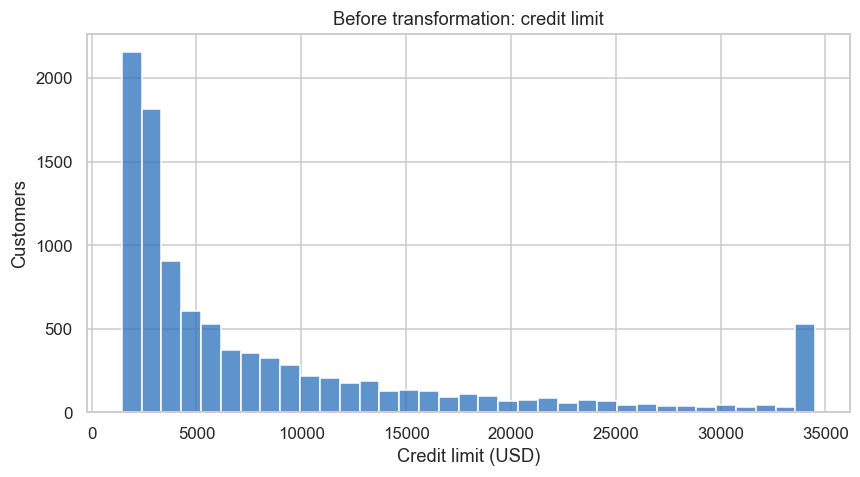

In [60]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv('BankChurners.csv')

plt.figure(figsize=(8, 4.5))
sns.histplot(df, x='Credit_Limit', bins=35, color='#2a6fbb', edgecolor='white')
plt.title('Before transformation: credit limit')
plt.xlabel('Credit limit (USD)')
plt.ylabel('Customers')
plt.tight_layout()
plt.show()

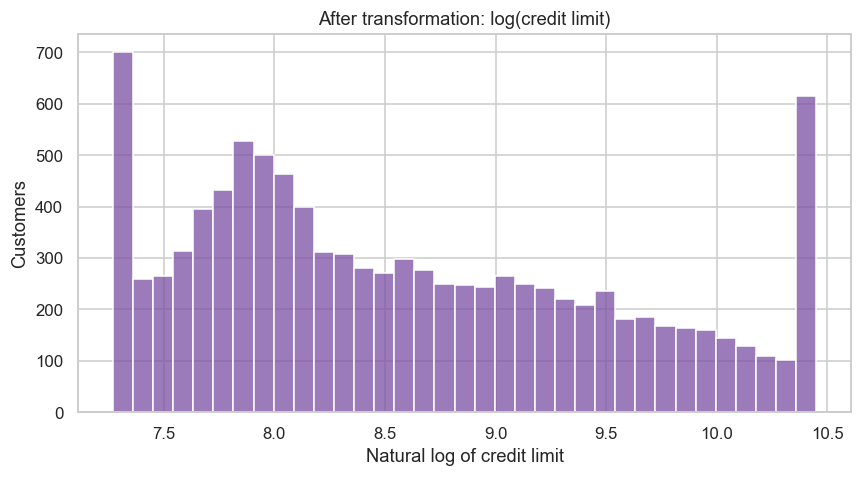

In [61]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv('BankChurners.csv')
df['Log_Credit_Limit'] = np.log(df['Credit_Limit'])

plt.figure(figsize=(8, 4.5))
sns.histplot(df, x='Log_Credit_Limit', bins=35, color='#7b4fa3', edgecolor='white')
plt.title('After transformation: log(credit limit)')
plt.xlabel('Natural log of credit limit')
plt.ylabel('Customers')
plt.tight_layout()
plt.show()

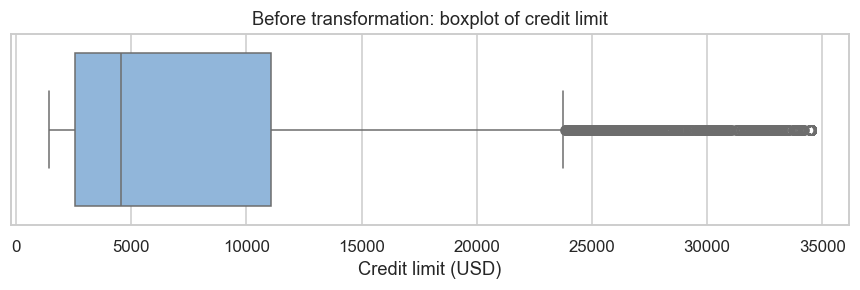

In [62]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv('BankChurners.csv')

plt.figure(figsize=(8, 2.8))
sns.boxplot(x=df['Credit_Limit'], color='#85b6e6')
plt.title('Before transformation: boxplot of credit limit')
plt.xlabel('Credit limit (USD)')
plt.tight_layout()
plt.show()

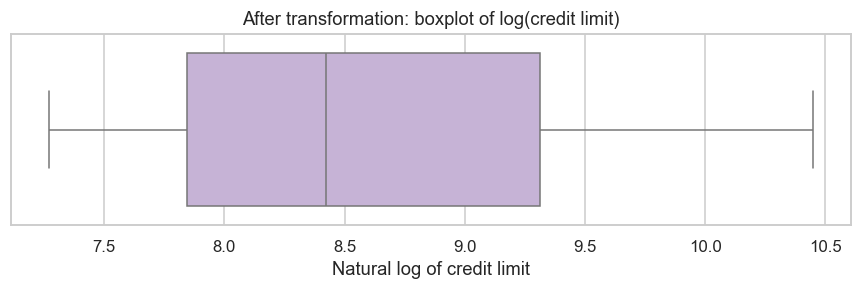

In [63]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv('BankChurners.csv')
df['Log_Credit_Limit'] = np.log(df['Credit_Limit'])

plt.figure(figsize=(8, 2.8))
sns.boxplot(x=df['Log_Credit_Limit'], color='#c7addc')
plt.title('After transformation: boxplot of log(credit limit)')
plt.xlabel('Natural log of credit limit')
plt.tight_layout()
plt.show()

## Part 6. Interpretation of the transformation

The log transformation reduces skewness from **1.67** to about **0.46**, so the distribution becomes substantially more symmetric. Its mean (8.603) and median (8.423) are closer than the original mean and median in their respective scales. The spread is compressed, and the original 984 upper IQR-rule potential outliers no longer fall outside the transformed IQR bounds. The transformation therefore reduces the visual and numerical influence of extreme credit limits.

We would use `Log_Credit_Limit` in a later model or a correlation/regression analysis when a less skewed predictor is useful. We would still report the original `Credit_Limit` in dollars for descriptive business communication, because it retains an intuitive scale. The transformation is useful here, but it is not automatically “better” for every analytical purpose.

## Part 7. What We Learned and New Questions

### Returning to an Assignment 1 question

Assignment 1 asked whether existing and attrited customers differ in transaction activity. The distributional analysis clarifies that `Total_Trans_Amt` is strongly right-skewed and has high-spending outliers. Therefore, the earlier difference in average transaction amount should be interpreted alongside medians and IQRs, not from means alone. The conclusion that attrited customers are less active remains meaningful, but the median is the more robust “typical customer” comparison for spending.

### New exploratory questions

1. Does the distribution of `Total_Trans_Amt` differ by attrition status after comparing medians and IQRs?
2. Are high `Credit_Limit` outliers concentrated in particular income or card categories?
3. Does log-transformed credit limit relate more linearly to transaction amount than the original credit limit?
4. Are customers with very high transaction counts also high spenders, or do they make many low-value transactions?

### Conclusion

The main finding is that the two monetary variables are strongly right-skewed, while annual transaction count is close to symmetric. `Total_Trans_Amt` is the most skewed original variable (skewness 2.04); `Credit_Limit` also has a long upper tail and 984 potential IQR outliers. The investigated extreme records are internally coherent and are retained, because they appear to be real customer profiles rather than errors. Robust statistics show why the median and IQR are more dependable for the monetary variables. A log transformation of credit limit markedly reduces skewness and is useful for later modelling, while original dollars remain best for communication. Next, we would investigate the new questions above, particularly robust comparisons of activity by attrition status.